# Avance 1: Análisis Exploratorio de Datos (EDA) - Sarampión y Vacunación en México 2010-2023
## Proyecto Integrador - Equipo 32

**Integrantes:**
- Luis Mauricio Castro Gutiérrez - A01795088
- Gerardo Miguel Pérez Solis - A01795599
- Amiel Joel Rosete Islas - A01748598

---

En este primer avance se realizó un Análisis Exploratorio de Datos con el objetivo de comprender la estructura del conjunto de datos, describir sus variables mediante técnicas de estadística descriptiva y visualización, e identificar patrones relevantes para el preprocesamiento y el modelado posterior. El EDA se desarrolló haciendo énfasis en: valores faltantes, valores atípicos, distribución de variables, tendencias temporales, estacionalidad, descomposición de series de tiempo y relaciones entre variables.

## 1. Configuración e Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import pearsonr, spearmanr, skew, kurtosis, mannwhitneyu
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, ccf

# Suprimir warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Librerías importadas correctamente')

Librerías importadas correctamente


## 2. Carga del Dataset

El dataset consolidado contiene información mensual de dosis de vacunas SRP aplicadas y casos de sarampión reportados en México.

Para la generación de este dataset se utilizaron los notebooks [DataPreparation_1](Data%20Preparation/DataPreparation_1_ScriptUnificadorDatasetBoletinanios.ipynb), [DataPreparation_2](Data%20Preparation/DataPreparation_2_ScriptUnificadorDatasetDosisanios.ipynb) y [DataPreparation_3](Data%20Preparation/DataPreparation_3_UnificadorDatasetsIncidenciasyVacunas.ipynb), que unifican los datasets de años históricos en una sola fuente.

In [2]:
base_path = Path(__file__).parent.parent if '__file__' in globals() else Path.cwd().parent
DATASET_FILE = f'{base_path}/data/processed/dataset_sarampion_vacunas_2010-2023.csv'

df = pd.read_csv(DATASET_FILE, encoding='utf-8')

# Crear columna de fecha para análisis temporal
df['fecha'] = pd.to_datetime(df['anio'].astype(str) + '-' + df['mes'].astype(str) + '-01')
df = df.sort_values('fecha').reset_index(drop=True)

print(f'Dataset cargado: {len(df)} registros, {len(df.columns)} columnas')
print(f'Período: {df["anio"].min()} - {df["anio"].max()}')
print(f'Columnas: {list(df.columns)}')

Dataset cargado: 168 registros, 5 columnas
Período: 2010 - 2023
Columnas: ['mes', 'anio', 'total_dosis', 'casos_sarampion', 'fecha']


## 3. Exploración Inicial

In [3]:
df.info()
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   mes              168 non-null    int64         
 1   anio             168 non-null    int64         
 2   total_dosis      168 non-null    int64         
 3   casos_sarampion  168 non-null    int64         
 4   fecha            168 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(4)
memory usage: 6.7 KB


,mes,anio,total_dosis,casos_sarampion,fecha
count,168.000000,168.00000,1.680000e+02,168.000000,168
mean,6.500000,2016.50000,3.153230e+05,2.261905,2016-12-15 16:17:08.571428608
min,1.000000,2010.00000,1.115500e+04,0.000000,2010-01-01 00:00:00
25%,3.750000,2013.00000,1.794778e+05,0.000000,2013-06-23 12:00:00
50%,6.500000,2016.50000,2.292330e+05,0.000000,2016-12-16 12:00:00
75%,9.250000,2020.00000,3.167408e+05,0.000000,2020-06-08 12:00:00
max,12.000000,2023.00000,3.130610e+06,81.000000,2023-12-01 00:00:00
std,3.462373,4.04318,3.567464e+05,11.132968,NaN


In [4]:
print('PRIMERAS 10 FILAS')
display(df.head(10))

print('\nÚLTIMAS 10 FILAS')
display(df.tail(10))

PRIMERAS 10 FILAS


,mes,anio,total_dosis,casos_sarampion,fecha
0,1,2010,180830,0,2010-01-01
1,2,2010,183377,0,2010-02-01
2,3,2010,242572,0,2010-03-01
3,4,2010,216429,0,2010-04-01
4,5,2010,174559,0,2010-05-01
5,6,2010,411045,0,2010-06-01
6,7,2010,229487,81,2010-07-01
7,8,2010,254698,25,2010-08-01
8,9,2010,206088,0,2010-09-01
9,10,2010,396236,15,2010-10-01



ÚLTIMAS 10 FILAS


,mes,anio,total_dosis,casos_sarampion,fecha
158,3,2023,318145,0,2023-03-01
159,4,2023,271352,0,2023-04-01
160,5,2023,285941,0,2023-05-01
161,6,2023,323897,0,2023-06-01
162,7,2023,319238,0,2023-07-01
163,8,2023,190148,0,2023-08-01
164,9,2023,322586,0,2023-09-01
165,10,2023,365603,0,2023-10-01
166,11,2023,316722,0,2023-11-01
167,12,2023,215309,0,2023-12-01


In [5]:
# Resumen por año
resumen_anual = df.groupby('anio').agg({
    'total_dosis': ['sum', 'mean'],
    'casos_sarampion': ['sum', 'mean']
}).round(0)
resumen_anual.columns = ['Dosis_Total', 'Dosis_Promedio_Mes', 'Casos_Total', 'Casos_Promedio_Mes']
display(resumen_anual)

,Dosis_Total,Dosis_Promedio_Mes,Casos_Total,Casos_Promedio_Mes
anio,,,,
2010,3297207,274767.0,125,10.0
2011,4121056,343421.0,0,0.0
2012,3301302,275108.0,0,0.0
2013,2753082,229424.0,41,3.0
2014,4385670,365472.0,0,0.0
2015,2982545,248545.0,0,0.0
2016,7996172,666348.0,0,0.0
2017,2297784,191482.0,0,0.0
2018,3141311,261776.0,4,0.0


### 3.1 Valores Faltantes

In [6]:
missing_data = pd.DataFrame({
    'Columna': df.columns,
    'Valores_Faltantes': df.isnull().sum().values,
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2).values
})
display(missing_data)

print(f'\nTotal de valores faltantes: {df.isnull().sum().sum()}')

,Columna,Valores_Faltantes,Porcentaje
0,mes,0,0.0
1,anio,0,0.0
2,total_dosis,0,0.0
3,casos_sarampion,0,0.0
4,fecha,0,0.0



Total de valores faltantes: 0


**Interpretación:** El dataset no contiene valores faltantes. Los 168 registros mensuales están completos para todas las variables, lo cual indica buena calidad de los datos provenientes de fuentes oficiales (DGIS y boletín epidemiológico). No se requiere imputación.

### 3.2 Valores Anómalos y Atípicos (Outliers)

In [7]:
print('VERIFICACIÓN DE VALORES ANÓMALOS')
print(f'Dosis negativas: {(df["total_dosis"] < 0).sum()}')
print(f'Casos negativos: {(df["casos_sarampion"] < 0).sum()}')
print(f'Dosis = 0: {(df["total_dosis"] == 0).sum()}')
print(f'Casos = 0: {(df["casos_sarampion"] == 0).sum()}')

# Detección de outliers con IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in ['total_dosis', 'casos_sarampion']:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    print(f'\n{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%), '
          f'rango esperado [{lb:,.0f}, {ub:,.0f}]')
    if len(outliers) > 0:
        print(f'  Top 5 valores: {outliers[col].nlargest(5).values}')

VERIFICACIÓN DE VALORES ANÓMALOS
Dosis negativas: 0
Casos negativos: 0
Dosis = 0: 0
Casos = 0: 151

total_dosis: 14 outliers (8.3%), rango esperado [-26,417, 522,635]
  Top 5 valores: [3130610 1997039 1857617 1458643 1443895]

casos_sarampion: 17 outliers (10.1%), rango esperado [0, 0]
  Top 5 valores: [81 75 75 41 32]


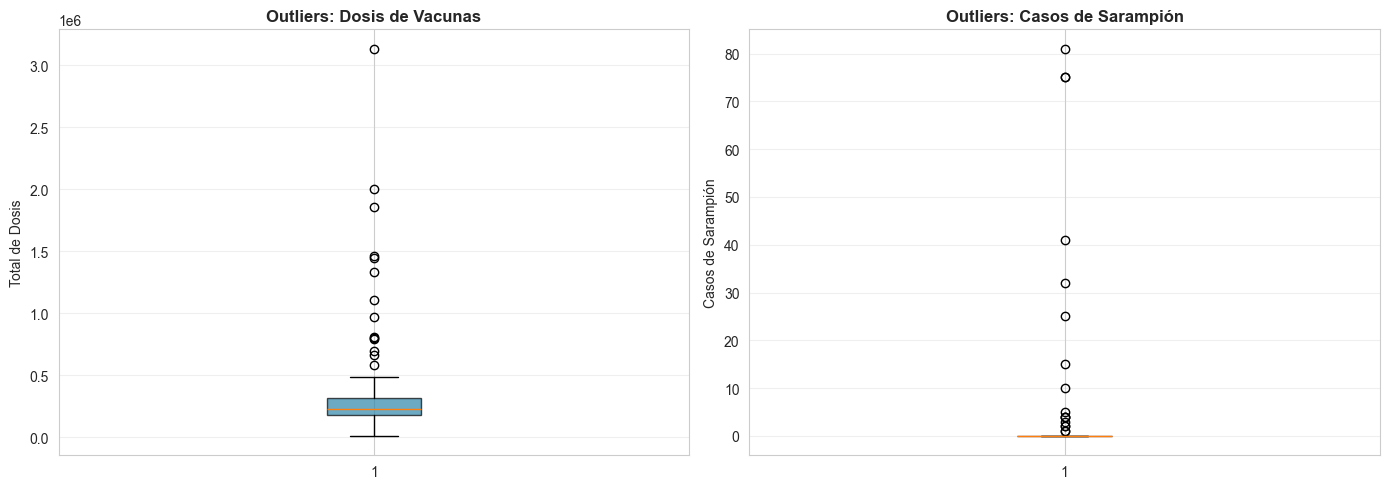

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['total_dosis'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2E86AB', alpha=0.7))
axes[0].set_ylabel('Total de Dosis')
axes[0].set_title('Outliers: Dosis de Vacunas', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].boxplot(df['casos_sarampion'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#A23B72', alpha=0.7))
axes[1].set_ylabel('Casos de Sarampión')
axes[1].set_title('Outliers: Casos de Sarampión', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Interpretación:** Se detectaron outliers en ambas variables, pero **no se eliminan** porque representan eventos reales:
- **Outliers en dosis**: Corresponden a campañas intensivas de vacunación (ej. octubre 2016 con 3.1M de dosis).
- **Outliers en casos**: Representan brotes epidemiológicos documentados (ej. julio 2010 con 81 casos).

Estos valores contienen información crítica para el análisis. Como alternativa para modelado, se aplica una transformación logarítmica para reducir la asimetría sin perder datos.

### 3.3 Distribuciones y Asimetría

total_dosis: skewness=4.703, kurtosis=27.404
casos_sarampion: skewness=5.897, kurtosis=35.334


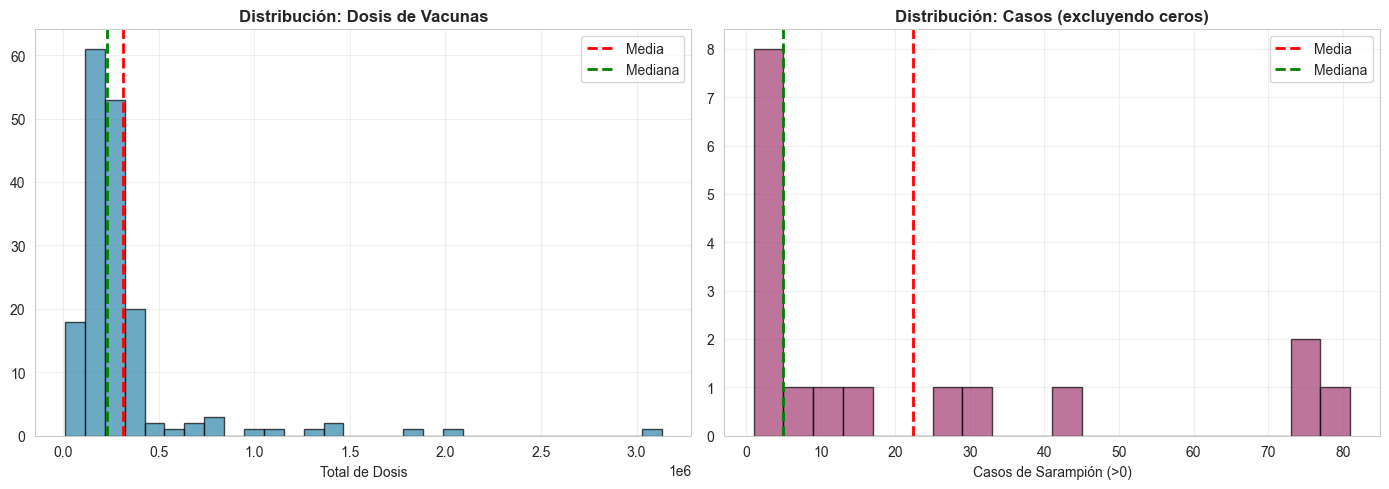

In [9]:
for var in ['total_dosis', 'casos_sarampion']:
    sk = skew(df[var])
    kt = kurtosis(df[var])
    print(f'{var}: skewness={sk:.3f}, kurtosis={kt:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['total_dosis'], bins=30, color='#2E86AB', alpha=0.7, edgecolor='black')
axes[0].axvline(df['total_dosis'].mean(), color='red', linestyle='--', lw=2, label='Media')
axes[0].axvline(df['total_dosis'].median(), color='green', linestyle='--', lw=2, label='Mediana')
axes[0].set_xlabel('Total de Dosis')
axes[0].set_title('Distribución: Dosis de Vacunas', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

casos_pos = df[df['casos_sarampion'] > 0]['casos_sarampion']
axes[1].hist(casos_pos, bins=20, color='#A23B72', alpha=0.7, edgecolor='black')
axes[1].axvline(casos_pos.mean(), color='red', linestyle='--', lw=2, label='Media')
axes[1].axvline(casos_pos.median(), color='green', linestyle='--', lw=2, label='Mediana')
axes[1].set_xlabel('Casos de Sarampión (>0)')
axes[1].set_title('Distribución: Casos (excluyendo ceros)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:** Ambas variables presentan alta asimetría positiva (sesgo a la derecha), lo cual es esperado en datos epidemiológicos de conteo:
- `total_dosis` tiene sesgo positivo debido a las campañas intensivas que elevan los valores.
- `casos_sarampion` es extremadamente sesgada porque la mayoría de los meses registran cero casos, con pocos meses de brotes.

Para modelado se aplicará transformación logarítmica `log(x+1)` que reduce la asimetría preservando el orden de los datos.

## 4. Análisis de Series Temporales

Dado que los datos son de naturaleza temporal (series mensuales), el análisis de tendencias, estacionalidad y descomposición es central para comprender el comportamiento de las variables.

### 4.1 Evolución Temporal

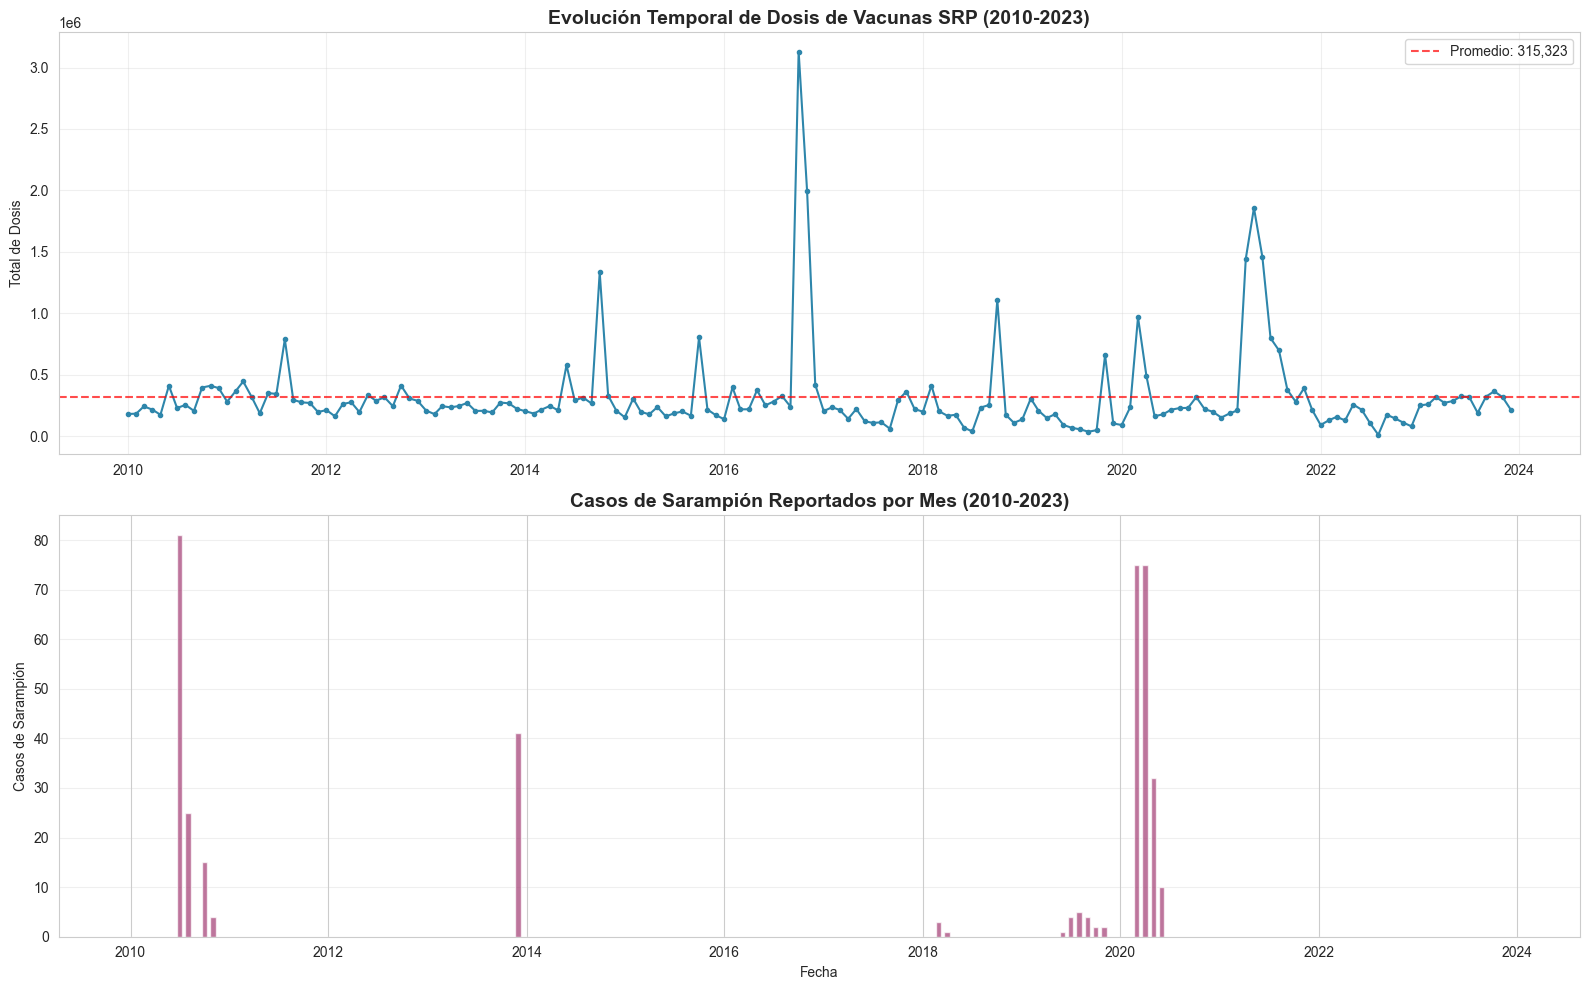

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Dosis de vacunas - línea continua
ax1.plot(df['fecha'], df['total_dosis'], linewidth=1.5, color='#2E86AB', marker='o', markersize=3)
ax1.axhline(y=df['total_dosis'].mean(), color='red', linestyle='--', alpha=0.7,
            label=f'Promedio: {df["total_dosis"].mean():,.0f}')
ax1.set_title('Evolución Temporal de Dosis de Vacunas SRP (2010-2023)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Total de Dosis')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Casos de sarampión - barras
ax2.bar(df['fecha'], df['casos_sarampion'], color='#A23B72', alpha=0.7, width=20)
ax2.set_title('Casos de Sarampión Reportados por Mes (2010-2023)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Casos de Sarampión')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 4.2 Tendencia Lineal

TENDENCIA LINEAL
Dosis:  pendiente=153.36 dosis/mes, R²=0.0004, p=0.7879
Casos:  pendiente=-0.0073 casos/mes, R²=0.0010, p=0.6796


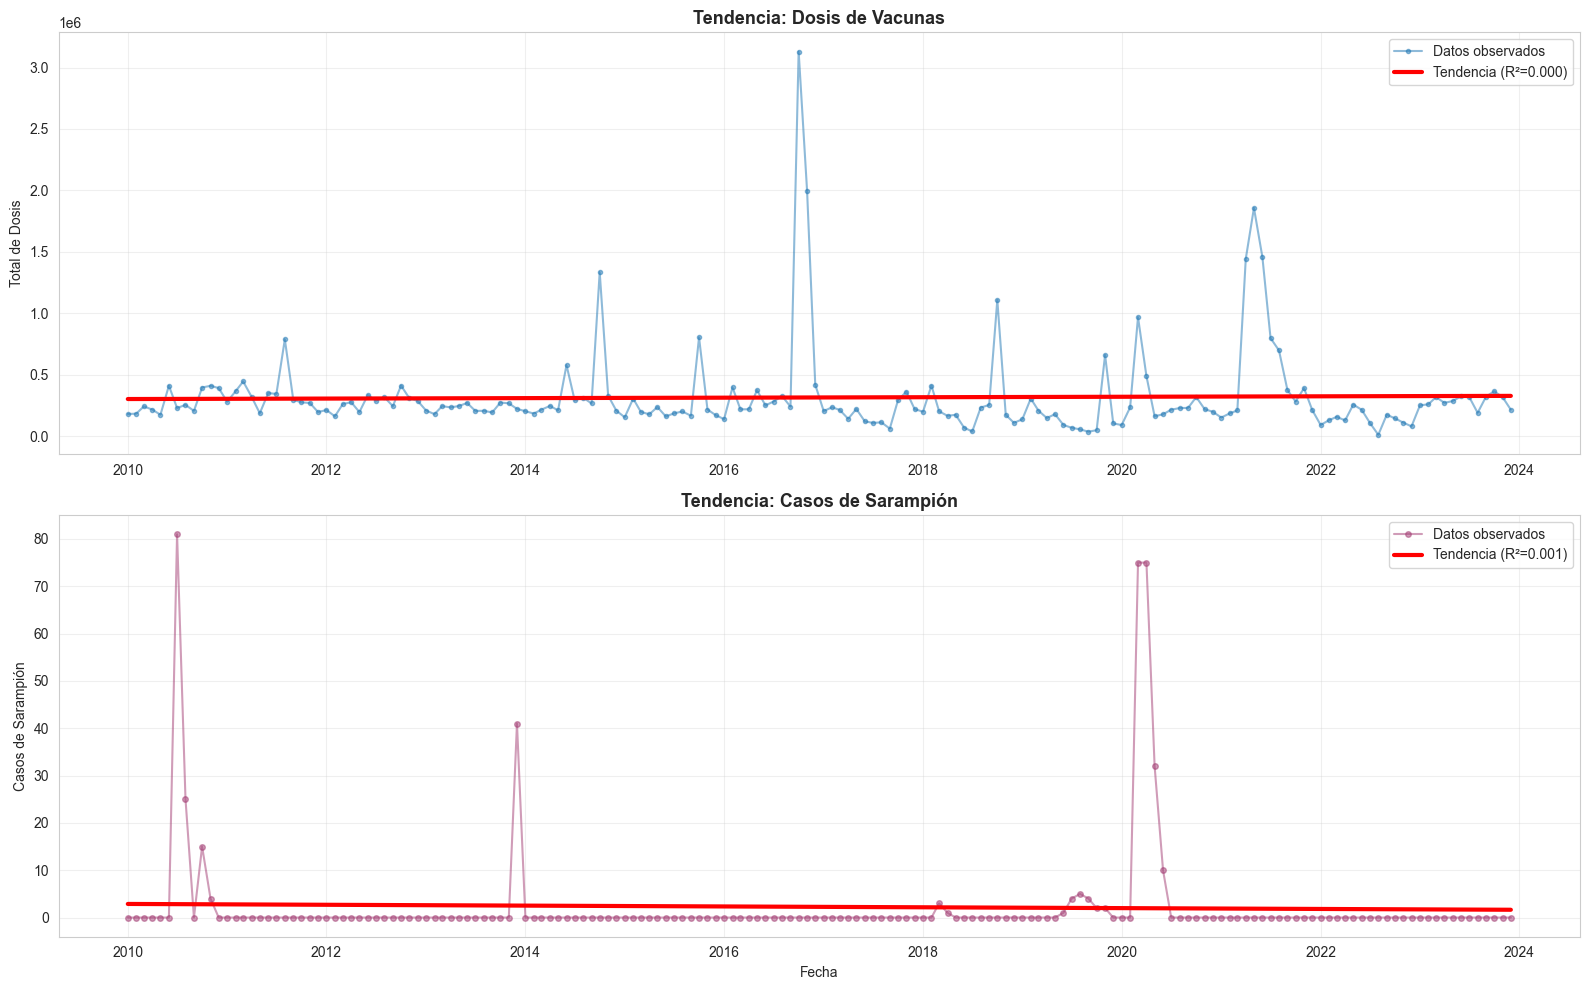

In [11]:
df['tiempo'] = range(len(df))

slope_d, intercept_d, r_d, p_d, _ = stats.linregress(df['tiempo'], df['total_dosis'])
slope_c, intercept_c, r_c, p_c, _ = stats.linregress(df['tiempo'], df['casos_sarampion'])

print('TENDENCIA LINEAL')
print(f'Dosis:  pendiente={slope_d:,.2f} dosis/mes, R²={r_d**2:.4f}, p={p_d:.4f}')
print(f'Casos:  pendiente={slope_c:.4f} casos/mes, R²={r_c**2:.4f}, p={p_c:.4f}')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

ax1.plot(df['fecha'], df['total_dosis'], 'o-', alpha=0.5, markersize=3, label='Datos observados')
ax1.plot(df['fecha'], slope_d * df['tiempo'] + intercept_d, 'r-', lw=3,
         label=f'Tendencia (R²={r_d**2:.3f})')
ax1.set_ylabel('Total de Dosis')
ax1.set_title('Tendencia: Dosis de Vacunas', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df['fecha'], df['casos_sarampion'], 'o-', alpha=0.5, markersize=4,
         color='#A23B72', label='Datos observados')
ax2.plot(df['fecha'], slope_c * df['tiempo'] + intercept_c, 'r-', lw=3,
         label=f'Tendencia (R²={r_c**2:.3f})')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Casos de Sarampión')
ax2.set_title('Tendencia: Casos de Sarampión', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:** Ninguna de las dos variables muestra tendencia lineal significativa:
- Las dosis de vacunas se mantienen relativamente estables a lo largo del período, sin incremento ni decremento sostenido.
- Los casos de sarampión son esporádicos y no siguen una tendencia lineal, sino que se presentan como brotes aislados.

Esto sugiere que la dinámica es no lineal, por lo que es necesario analizar los componentes de la serie de tiempo por separado.

### 4.3 Estacionalidad

,Dosis_Promedio,Dosis_Desv_Est,Casos_Total,Casos_Promedio
mes,,,,
1,179015.0,55033.0,0,0.0
2,253012.0,91214.0,0,0.0
3,293334.0,206266.0,78,6.0
4,319898.0,336469.0,76,5.0
5,340282.0,440338.0,32,2.0
6,344013.0,348970.0,11,1.0
7,248987.0,184776.0,85,6.0
8,281346.0,217235.0,30,2.0
9,219379.0,91871.0,4,0.0


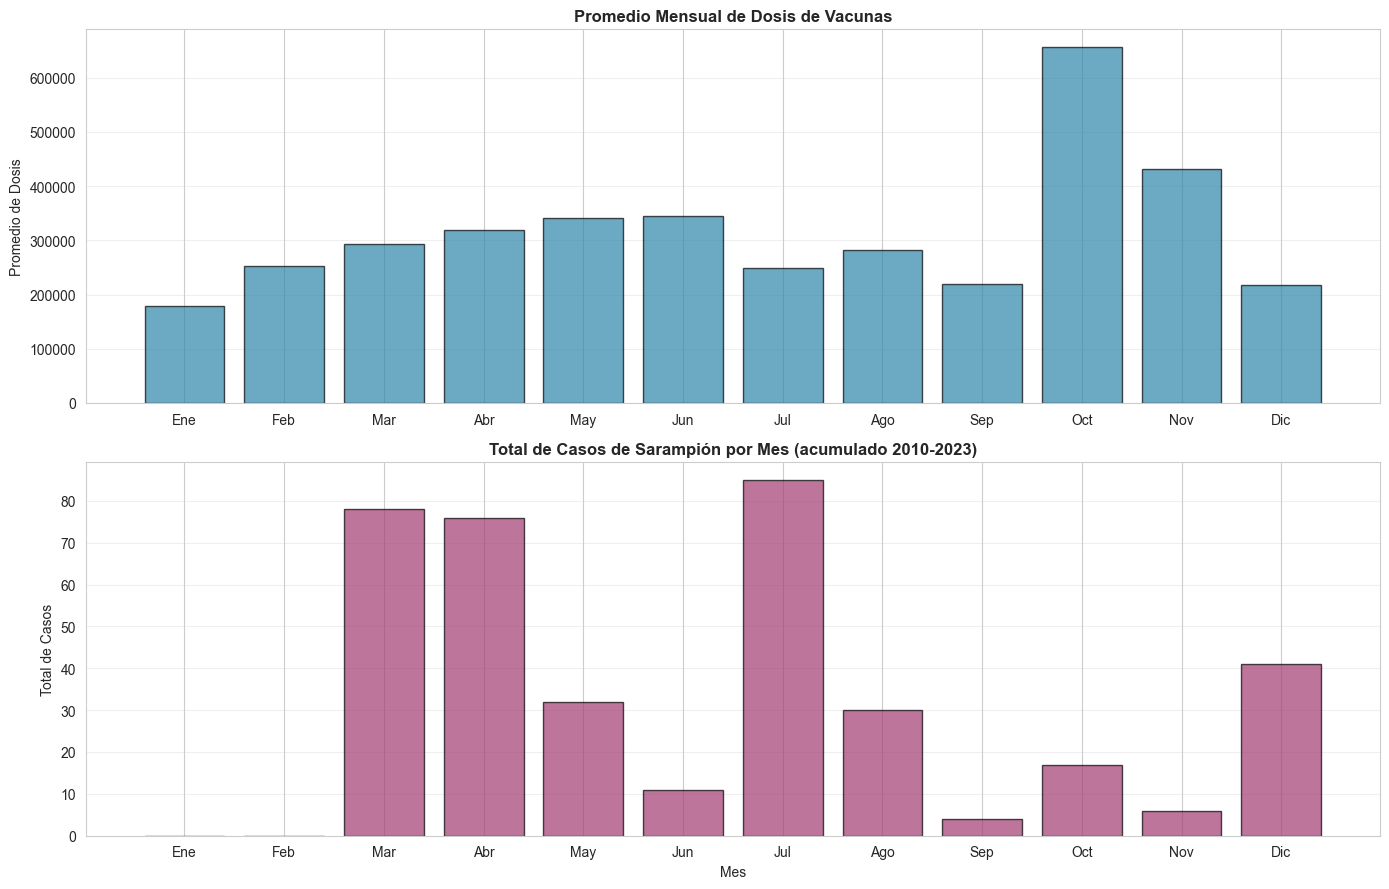

In [12]:
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

estacionalidad = df.groupby('mes').agg({
    'total_dosis': ['mean', 'std'],
    'casos_sarampion': ['sum', 'mean']
}).round(0)
estacionalidad.columns = ['Dosis_Promedio', 'Dosis_Desv_Est', 'Casos_Total', 'Casos_Promedio']
display(estacionalidad)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

ax1.bar(range(1, 13), estacionalidad['Dosis_Promedio'], color='#2E86AB', alpha=0.7, edgecolor='black')
ax1.set_title('Promedio Mensual de Dosis de Vacunas', fontweight='bold')
ax1.set_ylabel('Promedio de Dosis')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(meses_nombres)
ax1.grid(True, alpha=0.3, axis='y')

ax2.bar(range(1, 13), estacionalidad['Casos_Total'], color='#A23B72', alpha=0.7, edgecolor='black')
ax2.set_title('Total de Casos de Sarampión por Mes (acumulado 2010-2023)', fontweight='bold')
ax2.set_ylabel('Total de Casos')
ax2.set_xlabel('Mes')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(meses_nombres)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

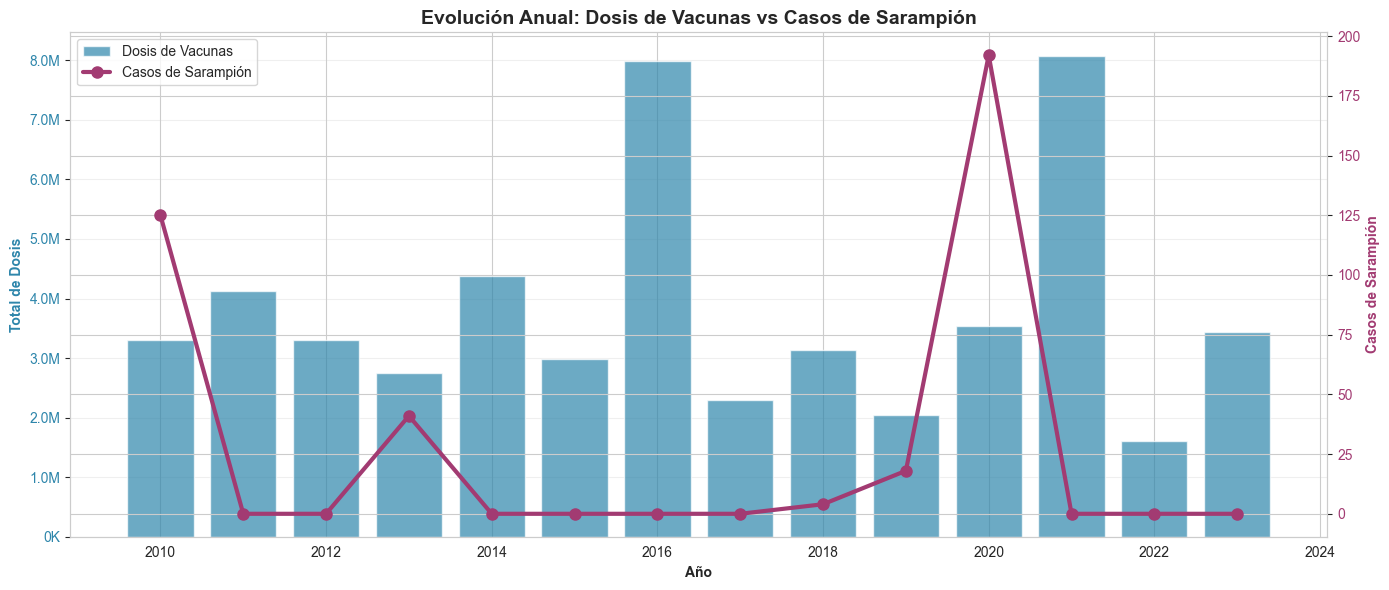

In [13]:
# Evolución anual: dosis vs casos
analisis_anual = df.groupby('anio').agg({
    'total_dosis': 'sum',
    'casos_sarampion': 'sum'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(analisis_anual['anio'], analisis_anual['total_dosis'],
        color='#2E86AB', alpha=0.7, label='Dosis de Vacunas')
ax1.set_xlabel('Año', fontweight='bold')
ax1.set_ylabel('Total de Dosis', color='#2E86AB', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, p: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))

ax2 = ax1.twinx()
ax2.plot(analisis_anual['anio'], analisis_anual['casos_sarampion'],
         color='#A23B72', marker='o', lw=3, markersize=8, label='Casos de Sarampión')
ax2.set_ylabel('Casos de Sarampión', color='#A23B72', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#A23B72')

plt.title('Evolución Anual: Dosis de Vacunas vs Casos de Sarampión', fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Interpretación:** Se observa un patrón estacional en la vacunación con variaciones entre meses. Los brotes de sarampión se concentran en años específicos (2010, 2013, 2018-2020), sin un patrón estacional claro. Los años con más casos no necesariamente coinciden con los de menor vacunación en términos absolutos, lo cual motiva un análisis más profundo con descomposición temporal y correlación cruzada.

### 4.4 Descomposición de la Serie de Tiempo

Descomponemos cada serie en sus tres componentes: **tendencia**, **estacionalidad** y **residuos (ruido)**, para entender qué parte de la variación es sistemática y cuál es aleatoria.

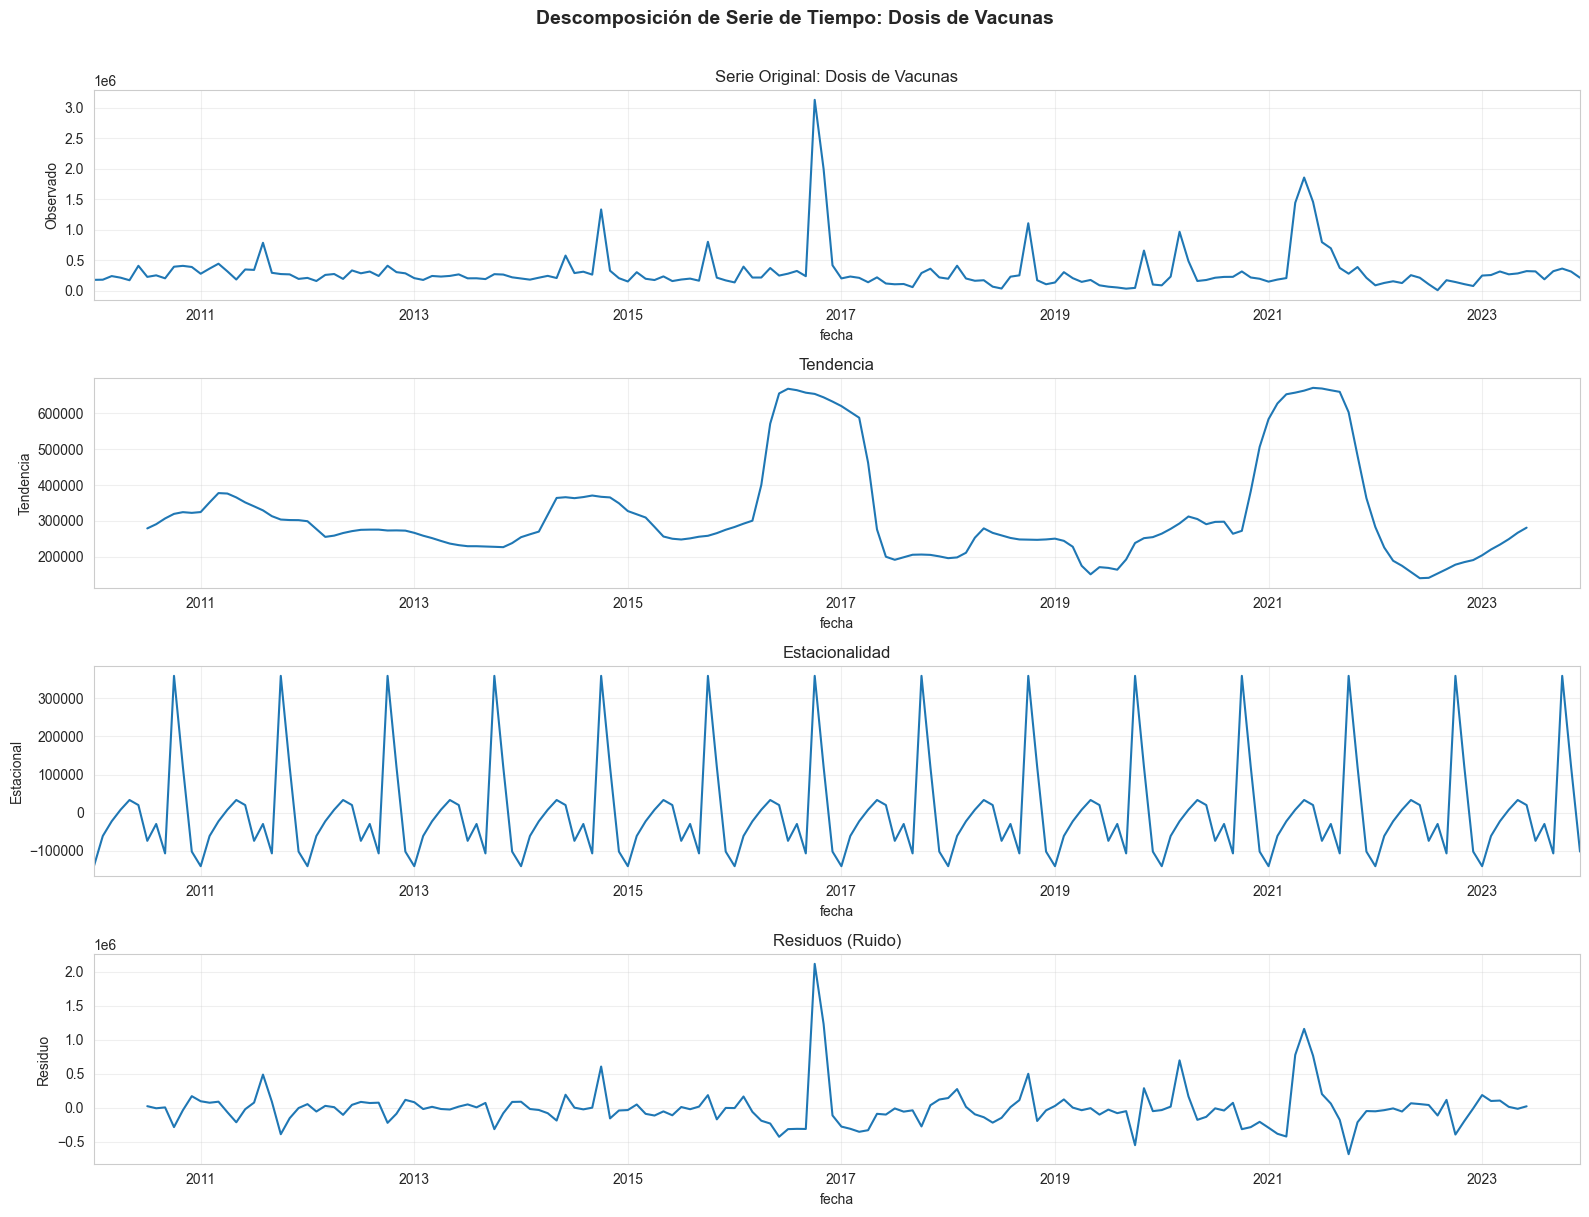

In [14]:
# Establecer fecha como índice para descomposición
df_ts = df.set_index('fecha')[['total_dosis', 'casos_sarampion']].copy()
df_ts.index.freq = 'MS'  # Frecuencia mensual

# Descomposición de dosis (aditiva)
decomp_dosis = seasonal_decompose(df_ts['total_dosis'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
decomp_dosis.observed.plot(ax=axes[0], title='Serie Original: Dosis de Vacunas')
axes[0].set_ylabel('Observado')
decomp_dosis.trend.plot(ax=axes[1], title='Tendencia')
axes[1].set_ylabel('Tendencia')
decomp_dosis.seasonal.plot(ax=axes[2], title='Estacionalidad')
axes[2].set_ylabel('Estacional')
decomp_dosis.resid.plot(ax=axes[3], title='Residuos (Ruido)')
axes[3].set_ylabel('Residuo')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle('Descomposición de Serie de Tiempo: Dosis de Vacunas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

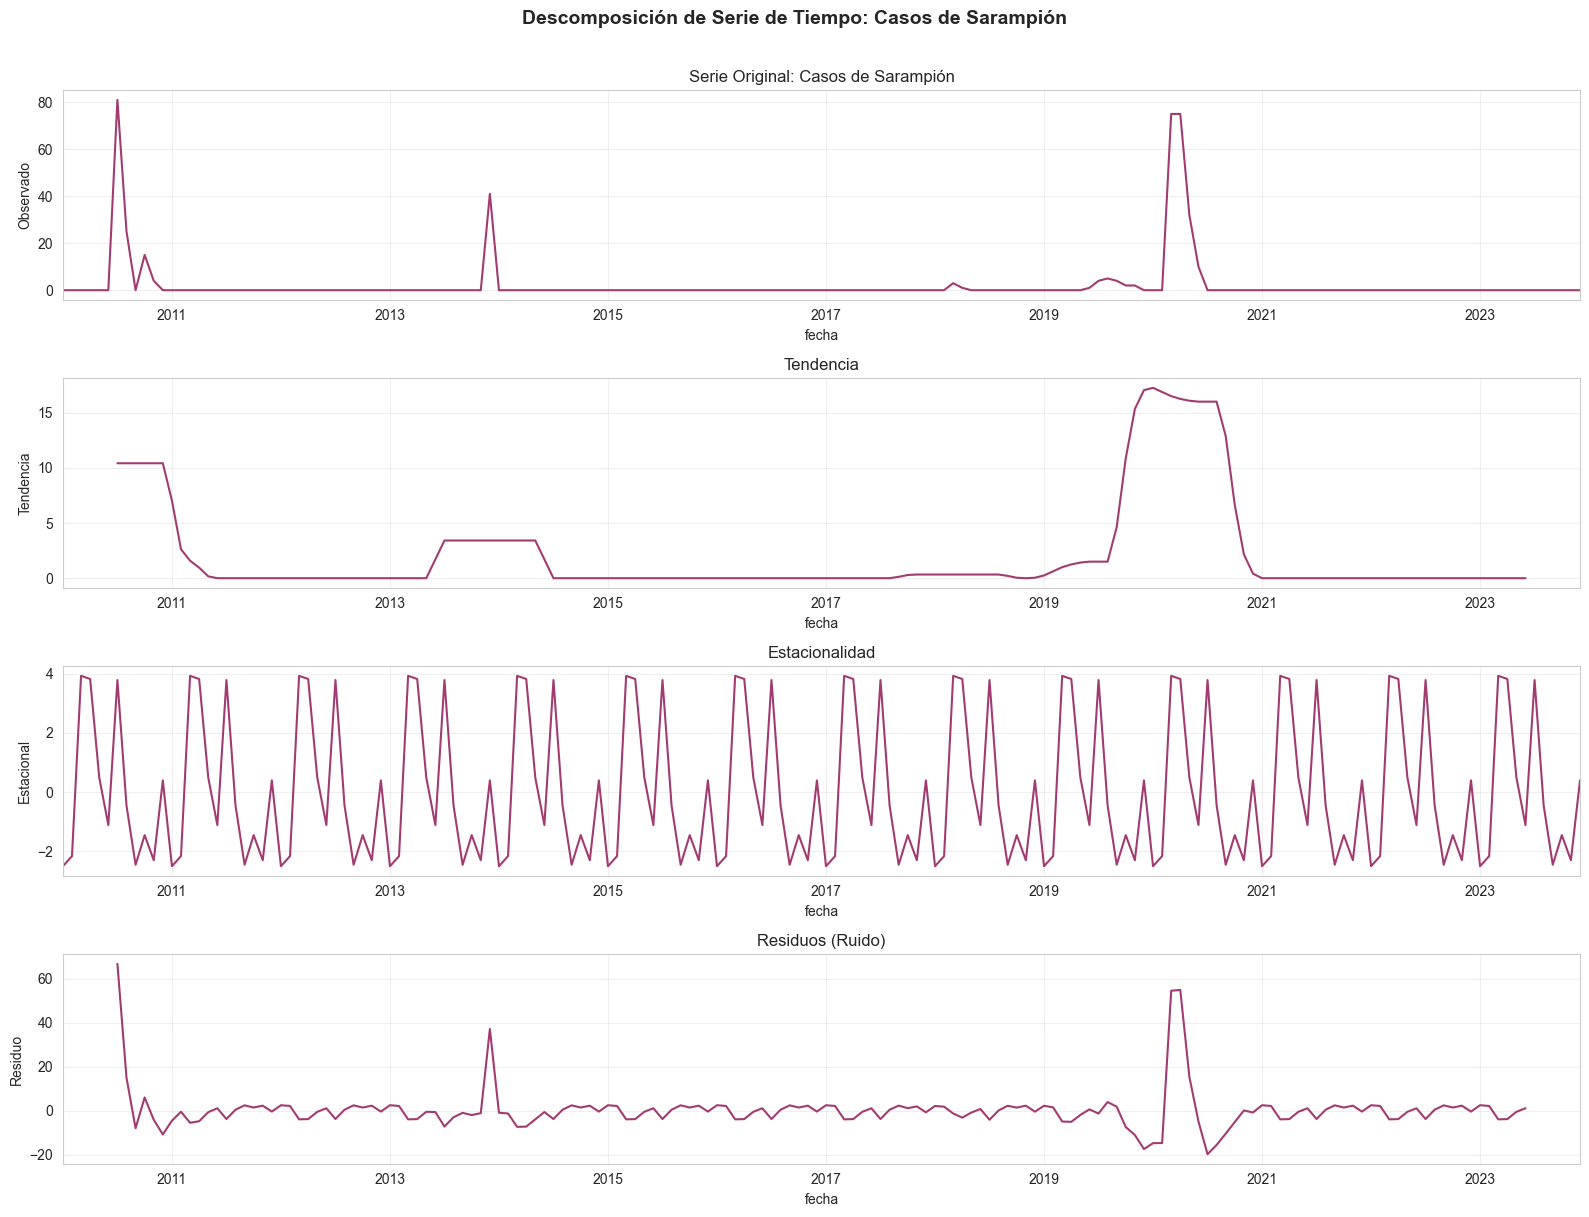

In [15]:
# Descomposición de casos de sarampión (aditiva)
decomp_casos = seasonal_decompose(df_ts['casos_sarampion'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
decomp_casos.observed.plot(ax=axes[0], title='Serie Original: Casos de Sarampión', color='#A23B72')
axes[0].set_ylabel('Observado')
decomp_casos.trend.plot(ax=axes[1], title='Tendencia', color='#A23B72')
axes[1].set_ylabel('Tendencia')
decomp_casos.seasonal.plot(ax=axes[2], title='Estacionalidad', color='#A23B72')
axes[2].set_ylabel('Estacional')
decomp_casos.resid.plot(ax=axes[3], title='Residuos (Ruido)', color='#A23B72')
axes[3].set_ylabel('Residuo')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle('Descomposición de Serie de Tiempo: Casos de Sarampión', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación de la descomposición:**
- **Dosis:** La tendencia muestra períodos de incremento y decremento (no lineal). Existe un componente estacional claro con picos recurrentes. Los residuos capturan las campañas intensivas extraordinarias.
- **Casos:** La tendencia refleja los períodos de brotes. La estacionalidad es débil dado que los brotes son eventos esporádicos. Los residuos contienen los picos de brotes que no se explican por la tendencia ni la estacionalidad.

### 4.5 Pruebas de Estacionaridad

Se aplican las pruebas **ADF** (Augmented Dickey-Fuller) y **KPSS** (Kwiatkowski-Phillips-Schmidt-Shin) para determinar si las series son estacionarias, lo cual es fundamental para la selección de modelos de series de tiempo.

In [16]:
def test_estacionaridad(serie, nombre):
    """Aplica pruebas ADF y KPSS a una serie de tiempo."""
    print(f'\n{"="*60}')
    print(f'PRUEBAS DE ESTACIONARIDAD: {nombre}')
    print(f'{"="*60}')
    
    # Test ADF
    # H0: La serie tiene raíz unitaria (NO es estacionaria)
    # H1: La serie NO tiene raíz unitaria (es estacionaria)
    adf_result = adfuller(serie.dropna(), autolag='AIC')
    print(f'\nTest ADF (Augmented Dickey-Fuller):')
    print(f'  Estadístico ADF: {adf_result[0]:.4f}')
    print(f'  P-value: {adf_result[1]:.6f}')
    print(f'  Lags usados: {adf_result[2]}')
    print(f'  Valores críticos:')
    for key, value in adf_result[4].items():
        print(f'    {key}: {value:.4f}')
    adf_estacionaria = adf_result[1] < 0.05
    print(f'  Conclusión: {"ESTACIONARIA" if adf_estacionaria else "NO ESTACIONARIA"} (p={adf_result[1]:.4f})')
    
    # Test KPSS
    # H0: La serie ES estacionaria
    # H1: La serie NO es estacionaria
    kpss_result = kpss(serie.dropna(), regression='c', nlags='auto')
    print(f'\nTest KPSS (Kwiatkowski-Phillips-Schmidt-Shin):')
    print(f'  Estadístico KPSS: {kpss_result[0]:.4f}')
    print(f'  P-value: {kpss_result[1]:.4f}')
    print(f'  Lags usados: {kpss_result[2]}')
    print(f'  Valores críticos:')
    for key, value in kpss_result[3].items():
        print(f'    {key}: {value:.4f}')
    kpss_estacionaria = kpss_result[1] > 0.05
    print(f'  Conclusión: {"ESTACIONARIA" if kpss_estacionaria else "NO ESTACIONARIA"} (p={kpss_result[1]:.4f})')
    
    # Resumen combinado
    print(f'\n  RESUMEN:')
    if adf_estacionaria and kpss_estacionaria:
        print(f'  Ambas pruebas confirman: SERIE ESTACIONARIA')
    elif not adf_estacionaria and not kpss_estacionaria:
        print(f'  Ambas pruebas confirman: SERIE NO ESTACIONARIA')
    else:
        print(f'  Resultados contradictorios: ADF={"Est." if adf_estacionaria else "No Est."}, KPSS={"Est." if kpss_estacionaria else "No Est."}')
        print(f'  Posible estacionaridad con tendencia o diferenciación requerida.')

test_estacionaridad(df_ts['total_dosis'], 'Dosis de Vacunas')


PRUEBAS DE ESTACIONARIDAD: Dosis de Vacunas

Test ADF (Augmented Dickey-Fuller):
  Estadístico ADF: -7.4529
  P-value: 0.000000
  Lags usados: 1
  Valores críticos:
    1%: -3.4704
    5%: -2.8791
    10%: -2.5761
  Conclusión: ESTACIONARIA (p=0.0000)

Test KPSS (Kwiatkowski-Phillips-Schmidt-Shin):
  Estadístico KPSS: 0.0438
  P-value: 0.1000
  Lags usados: 4
  Valores críticos:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
  Conclusión: ESTACIONARIA (p=0.1000)

  RESUMEN:
  Ambas pruebas confirman: SERIE ESTACIONARIA


In [17]:
test_estacionaridad(df_ts['casos_sarampion'], 'Casos de Sarampión')


PRUEBAS DE ESTACIONARIDAD: Casos de Sarampión

Test ADF (Augmented Dickey-Fuller):
  Estadístico ADF: -7.3721
  P-value: 0.000000
  Lags usados: 1
  Valores críticos:
    1%: -3.4704
    5%: -2.8791
    10%: -2.5761
  Conclusión: ESTACIONARIA (p=0.0000)

Test KPSS (Kwiatkowski-Phillips-Schmidt-Shin):
  Estadístico KPSS: 0.0751
  P-value: 0.1000
  Lags usados: 5
  Valores críticos:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
  Conclusión: ESTACIONARIA (p=0.1000)

  RESUMEN:
  Ambas pruebas confirman: SERIE ESTACIONARIA


**Interpretación:** Las pruebas de estacionaridad indican si las series pueden modelarse directamente o requieren diferenciación:
- Ambas pruebas coinciden en estacionaridad, por lo que la serie puede usarse directamente en modelos como ARIMA, Prophet, Poisson, Negative Binomial, Z-scores, Isolation Forest, Bayesian Hierarchical Models, State Space.

## 5. Correlación y Relación entre Variables

### 5.1 Correlación entre Dosis y Casos

Se calcula la correlación únicamente entre `total_dosis` y `casos_sarampion`, que son las variables numéricas continuas del dataset. No se incluyen `anio` ni `mes` en la correlación de Pearson, ya que Pearson asume variables numéricas continuas y estas variables son ordinales/cíclicas respectivamente.

CORRELACIÓN: total_dosis vs casos_sarampion
  Pearson:  r=0.0620, p=0.4249
  Spearman: rho=-0.0747, p=0.3359


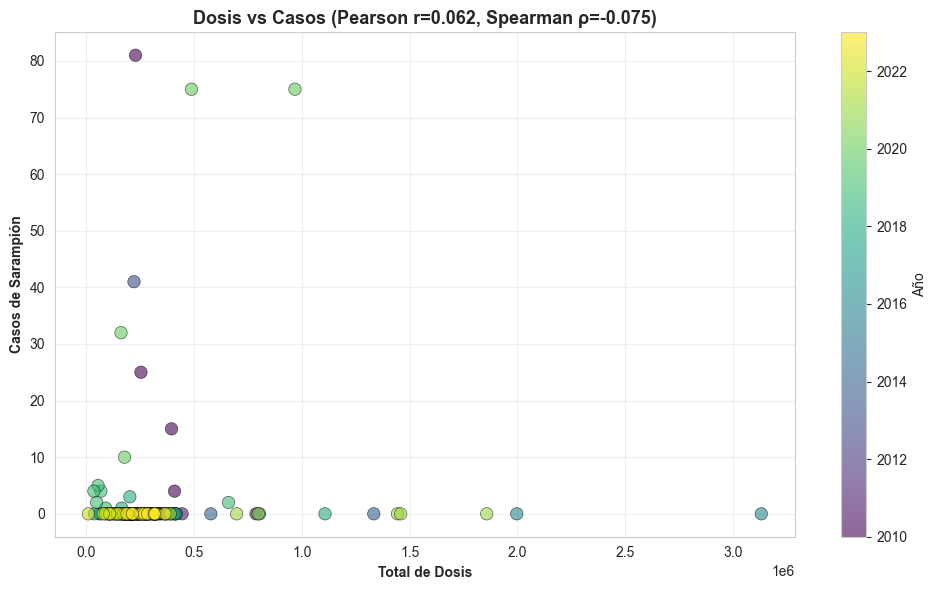

In [18]:
# Correlación solo entre variables continuas
pearson_corr, pearson_p = pearsonr(df['total_dosis'], df['casos_sarampion'])
spearman_corr, spearman_p = spearmanr(df['total_dosis'], df['casos_sarampion'])

print('CORRELACIÓN: total_dosis vs casos_sarampion')
print(f'  Pearson:  r={pearson_corr:.4f}, p={pearson_p:.4f}')
print(f'  Spearman: rho={spearman_corr:.4f}, p={spearman_p:.4f}')

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['total_dosis'], df['casos_sarampion'],
                     c=df['anio'], cmap='viridis', s=80, alpha=0.6,
                     edgecolors='black', linewidth=0.5)
ax.set_xlabel('Total de Dosis', fontweight='bold')
ax.set_ylabel('Casos de Sarampión', fontweight='bold')
ax.set_title(f'Dosis vs Casos (Pearson r={pearson_corr:.3f}, Spearman ρ={spearman_corr:.3f})',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Año')
plt.tight_layout()
plt.show()

**Interpretación:** La correlación contemporánea (sin desfase) entre dosis y casos es muy débil. Esto no necesariamente indica que no hay relación, sino que:
1. La mayoría de los meses tienen cero casos, lo que dificulta detectar correlación lineal.
2. El efecto de la vacunación en la incidencia probablemente tiene un **desfase temporal** (la protección no es inmediata).
3. Es necesario explorar la relación con lags usando correlación cruzada (CCF).

### 5.2 Correlación Cruzada (CCF)

La **Cross-Correlation Function** permite identificar en qué lag (desfase temporal) la relación entre dosis y casos es más fuerte. Esto es clave para detectar si un cambio en la vacunación se refleja en los casos semanas o meses después.

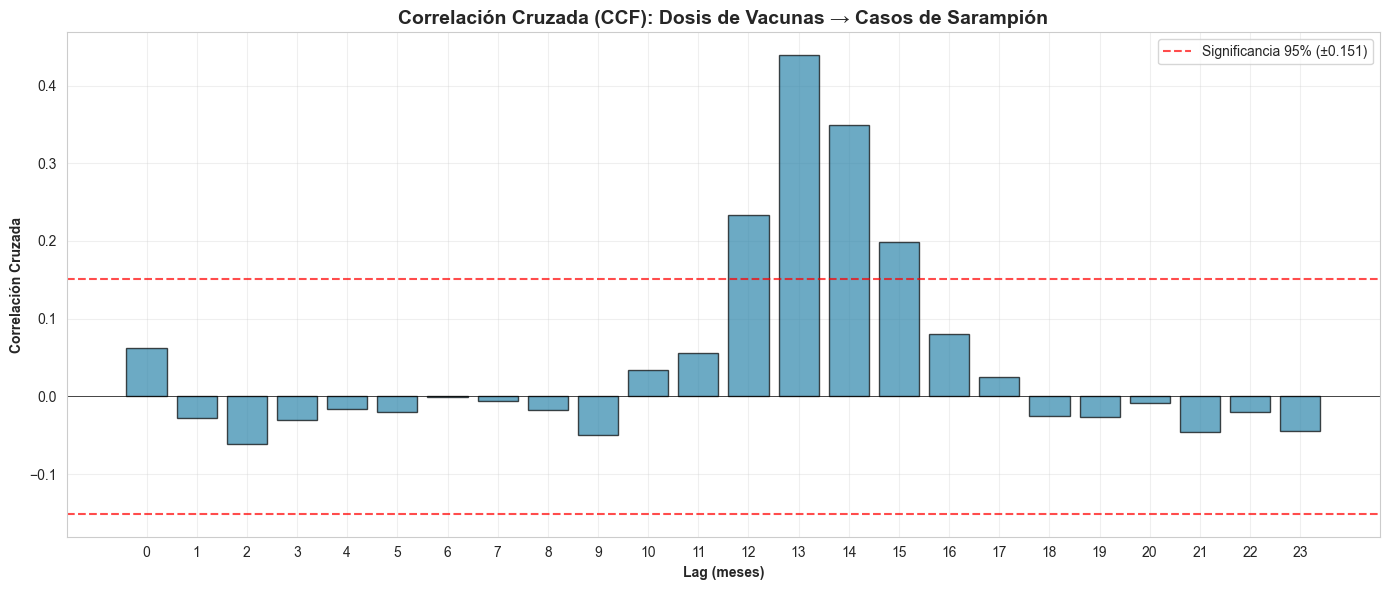


Lags con correlación significativa (|CCF| > 0.151):
  Lag 12: CCF = 0.2328
  Lag 13: CCF = 0.4391
  Lag 14: CCF = 0.3496
  Lag 15: CCF = 0.1991

✅ El Lag más fuerte es el 13 con una correlación de 0.4391


In [19]:
# Calcular CCF entre dosis y casos
max_lags = 24  # Hasta 24 meses de desfase

# Normalizar las series para CCF
dosis_norm = (df['total_dosis'] - df['total_dosis'].mean()) / df['total_dosis'].std()
casos_norm = (df['casos_sarampion'] - df['casos_sarampion'].mean()) / df['casos_sarampion'].std()

# Cross-correlation
ccf_values = ccf(dosis_norm, casos_norm, nlags=max_lags, alpha=0.05)

# ccf retorna (ccf_values, confint) cuando alpha es dado
ccf_vals = ccf_values[0] if isinstance(ccf_values, tuple) else ccf_values
if isinstance(ccf_values, tuple) and len(ccf_values) > 1:
    confint = ccf_values[1]
else:
    confint = None

# Visualización
fig, ax = plt.subplots(figsize=(14, 6))
lags = np.arange(0, len(ccf_vals))

ax.bar(lags, ccf_vals, color='#2E86AB', alpha=0.7, edgecolor='black')

# Bandas de significancia (95%)
n = len(df)
sig_level = 1.96 / np.sqrt(n)
ax.axhline(y=sig_level, color='red', linestyle='--', alpha=0.7, label=f'Significancia 95% (±{sig_level:.3f})')
ax.axhline(y=-sig_level, color='red', linestyle='--', alpha=0.7)
ax.axhline(y=0, color='black', linewidth=0.5)

ax.set_xlabel('Lag (meses)', fontweight='bold')
ax.set_ylabel('Correlación Cruzada', fontweight='bold')
ax.set_title('Correlación Cruzada (CCF): Dosis de Vacunas → Casos de Sarampión',
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(lags)

plt.tight_layout()
plt.show()

# Identificar lags significativos
best_lag = None
max_abs_corr = 0
best_ccf_val = 0
print('\nLags con correlación significativa (|CCF| > {:.3f}):'.format(sig_level))
for i, val in enumerate(ccf_vals):
    if abs(val) > sig_level:
        print(f'  Lag {i}: CCF = {val:.4f}')
        if abs(val) > max_abs_corr:
            max_abs_corr = abs(val)
            best_lag = i
            best_ccf_val = val
if best_lag is not None:
    print(f"\n✅ El Lag más fuerte es el {best_lag} con una correlación de {best_ccf_val:.4f}")
else:
    print("\n❌ No se encontraron lags significativos.")

**Interpretación:** La CCF muestra en qué desfase temporal (lag en meses) la correlación entre vacunación y casos es muy baja de apenas 0.4. Este resultado debe validarse con las doctoras del dominio para confirmar que el desfase tiene sentido epidemiológicoo validar con que otro método hacer la correlación para obtener emjores resultados.

### 5.3 Heatmaps: Patrones por Mes y Año

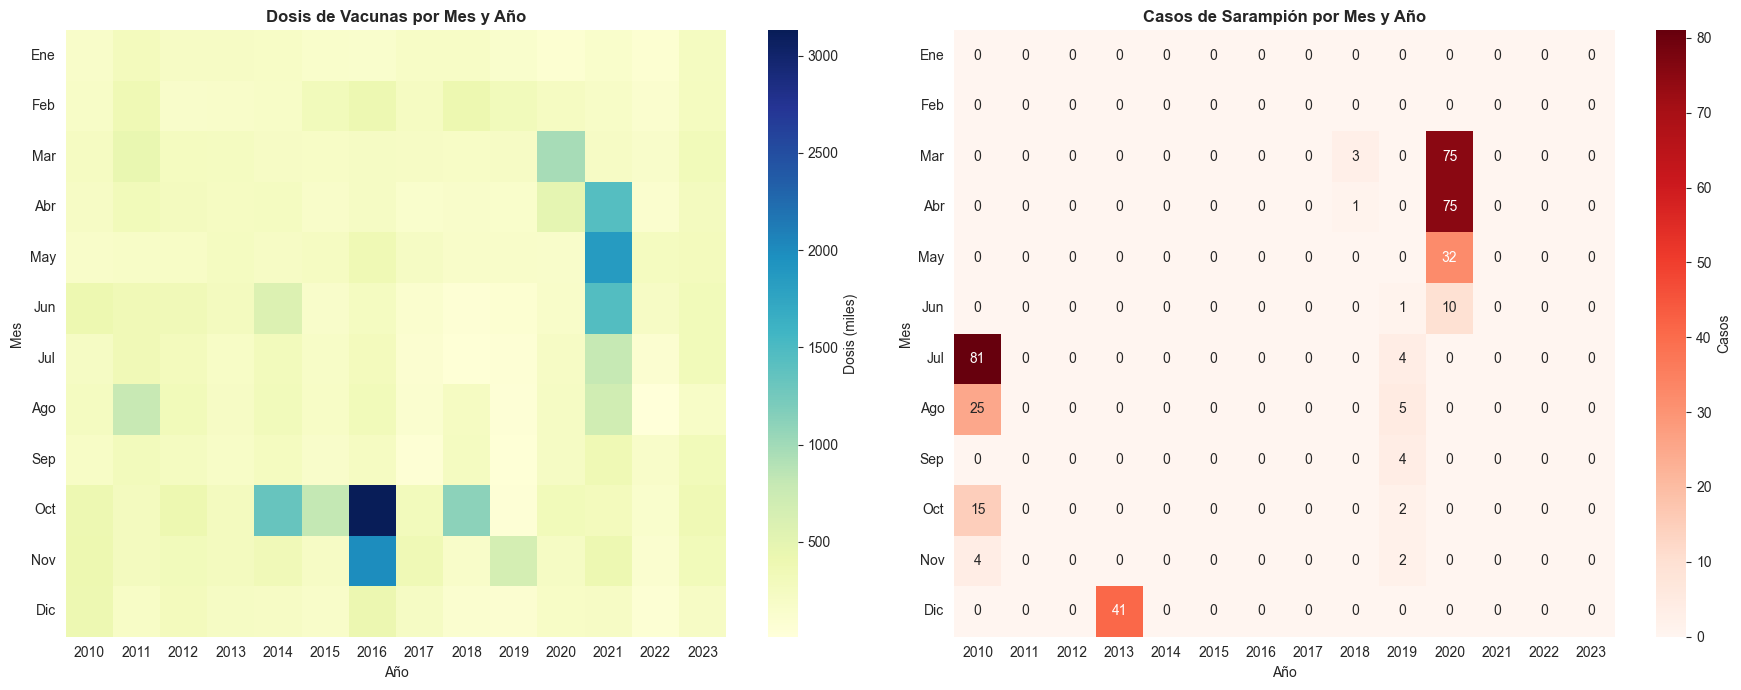

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap de dosis
pivot_dosis = df.pivot_table(values='total_dosis', index='mes', columns='anio', aggfunc='mean')
sns.heatmap(pivot_dosis / 1000, cmap='YlGnBu', annot=False,
            cbar_kws={'label': 'Dosis (miles)'}, ax=axes[0])
axes[0].set_title('Dosis de Vacunas por Mes y Año', fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Mes')
axes[0].set_yticklabels(meses_nombres, rotation=0)

# Heatmap de casos
pivot_casos = df.pivot_table(values='casos_sarampion', index='mes', columns='anio', aggfunc='mean')
sns.heatmap(pivot_casos, cmap='Reds', annot=True, fmt='.0f',
            cbar_kws={'label': 'Casos'}, ax=axes[1])
axes[1].set_title('Casos de Sarampión por Mes y Año', fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Mes')
axes[1].set_yticklabels(meses_nombres, rotation=0)

plt.tight_layout()
plt.show()

## 6. Identificación de Brotes y Campañas de Vacunación

### 6.1 Meses con Brotes

Definimos una **única variable binaria** `tiene_brote` que indica si en un mes se reportaron casos de sarampión (`casos_sarampion > 0`).

In [21]:
# Variable binaria única
df['tiene_brote'] = (df['casos_sarampion'] > 0).astype(int)

print('DISTRIBUCIÓN DE BROTES')
print(f'  Meses sin brote (0): {(df["tiene_brote"] == 0).sum()} ({(df["tiene_brote"] == 0).mean()*100:.1f}%)')
print(f'  Meses con brote (1): {(df["tiene_brote"] == 1).sum()} ({(df["tiene_brote"] == 1).mean()*100:.1f}%)')
print(f'  Ratio de desequilibrio: {(df["tiene_brote"] == 0).sum() / (df["tiene_brote"] == 1).sum():.1f}:1')

# Meses con casos
print('\nMESES CON CASOS DE SARAMPIÓN:')
casos_positivos = df[df['tiene_brote'] == 1].sort_values('casos_sarampion', ascending=False)
display(casos_positivos[['fecha', 'anio', 'mes', 'casos_sarampion', 'total_dosis']])

DISTRIBUCIÓN DE BROTES
  Meses sin brote (0): 151 (89.9%)
  Meses con brote (1): 17 (10.1%)
  Ratio de desequilibrio: 8.9:1

MESES CON CASOS DE SARAMPIÓN:


,fecha,anio,mes,casos_sarampion,total_dosis
6,2010-07-01,2010,7,81,229487
122,2020-03-01,2020,3,75,968432
123,2020-04-01,2020,4,75,488881
47,2013-12-01,2013,12,41,222406
124,2020-05-01,2020,5,32,162168
7,2010-08-01,2010,8,25,254698
9,2010-10-01,2010,10,15,396236
125,2020-06-01,2020,6,10,178562
115,2019-08-01,2019,8,5,55815
10,2010-11-01,2010,11,4,410222


,Meses_con_brote,Total_meses,Porcentaje
anio,,,
2010,4,12,33.3
2011,0,12,0.0
2012,0,12,0.0
2013,1,12,8.3
2014,0,12,0.0
2015,0,12,0.0
2016,0,12,0.0
2017,0,12,0.0
2018,2,12,16.7


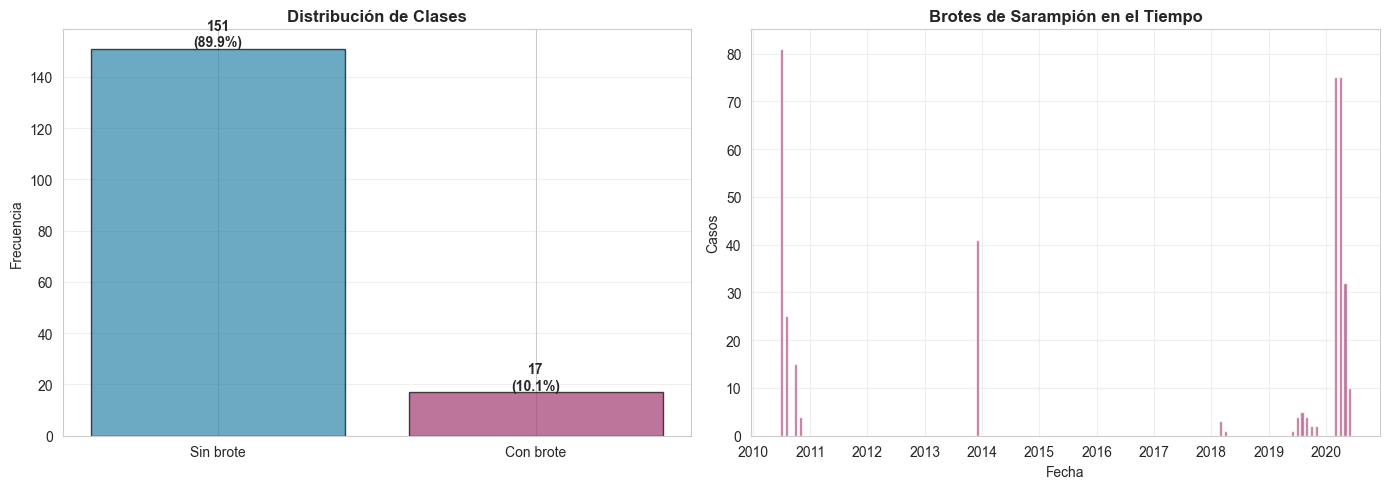

In [22]:
# Distribución de brotes por año
brotes_anual = df.groupby('anio')['tiene_brote'].agg(['sum', 'count'])
brotes_anual['porcentaje'] = (brotes_anual['sum'] / brotes_anual['count'] * 100).round(1)
brotes_anual.columns = ['Meses_con_brote', 'Total_meses', 'Porcentaje']
display(brotes_anual)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de clases
counts = df['tiene_brote'].value_counts()
axes[0].bar(['Sin brote', 'Con brote'], counts.values,
           color=['#2E86AB', '#A23B72'], alpha=0.7, edgecolor='black')
for i, v in enumerate(counts.values):
    pct = v / len(df) * 100
    axes[0].text(i, v + 1, f'{v}\n({pct:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Distribución de Clases', fontweight='bold')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True, alpha=0.3, axis='y')

# Timeline
axes[1].bar(df[df['tiene_brote']==1]['fecha'], df[df['tiene_brote']==1]['casos_sarampion'],
            color='#A23B72', alpha=0.7, width=20)
axes[1].set_title('Brotes de Sarampión en el Tiempo', fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Casos')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:** Existe un desequilibrio de clases esperado: ~90% de los meses no registran casos. Esto refleja el éxito del programa de vacunación, pero representa un reto para el modelado predictivo. Para la predicción de brotes en series de tiempo, **no se recomienda usar SMOTE** u otras técnicas de oversampling sintético, ya que pueden generar *data leakage* al no respetar el orden temporal. En su lugar, se recomienda:
- Usar pesos de clase (`class_weight`) en modelos.
- Métricas apropiadas: F1-Score, AUC-ROC, Recall.
- Validación cruzada con partición temporal.

Exploraremos estas alternativas.

### 6.2 Campañas Intensivas de Vacunación

Umbral de campaña intensiva: 1,028,816 dosis
Meses identificados: 7


,fecha,anio,mes,total_dosis,casos_sarampion
81,2016-10-01,2016,10,3130610,0
82,2016-11-01,2016,11,1997039,0
136,2021-05-01,2021,5,1857617,0
137,2021-06-01,2021,6,1458643,0
135,2021-04-01,2021,4,1443895,0
57,2014-10-01,2014,10,1334201,0
105,2018-10-01,2018,10,1107877,0


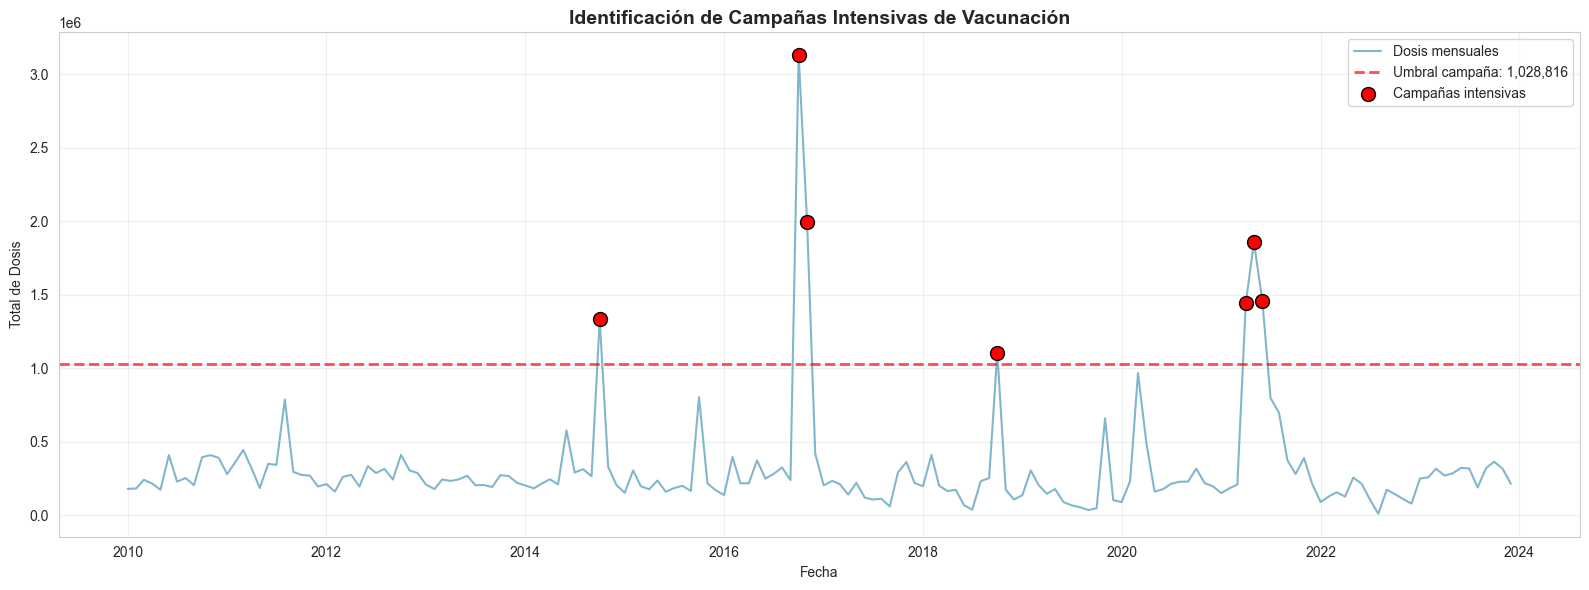

In [23]:
# Identificar meses con dosis > 2 desviaciones estándar sobre la media
umbral_alto = df['total_dosis'].mean() + 2 * df['total_dosis'].std()
campanas = df[df['total_dosis'] > umbral_alto].sort_values('total_dosis', ascending=False)

print(f'Umbral de campaña intensiva: {umbral_alto:,.0f} dosis')
print(f'Meses identificados: {len(campanas)}')
if len(campanas) > 0:
    display(campanas[['fecha', 'anio', 'mes', 'total_dosis', 'casos_sarampion']])

# Visualización
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['fecha'], df['total_dosis'], lw=1.5, color='#2E86AB', alpha=0.6, label='Dosis mensuales')
ax.axhline(y=umbral_alto, color='red', linestyle='--', lw=2,
           label=f'Umbral campaña: {umbral_alto:,.0f}', alpha=0.7)
if len(campanas) > 0:
    ax.scatter(campanas['fecha'], campanas['total_dosis'],
               color='red', s=100, zorder=5, label='Campañas intensivas', edgecolors='black')
ax.set_title('Identificación de Campañas Intensivas de Vacunación', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Total de Dosis')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Comparación: Meses con vs sin Brotes (con lag temporal)

COMPARACIÓN DESCRIPTIVA: Dosis en meses con/sin brotes
  Sin brote - Media: 320,079, Mediana: 232,968
  Con brote - Media: 273,077, Mediana: 203,073

Mann-Whitney U (comparación contemporánea): U=1493.00, p=0.2717
  No significativo al nivel 0.05


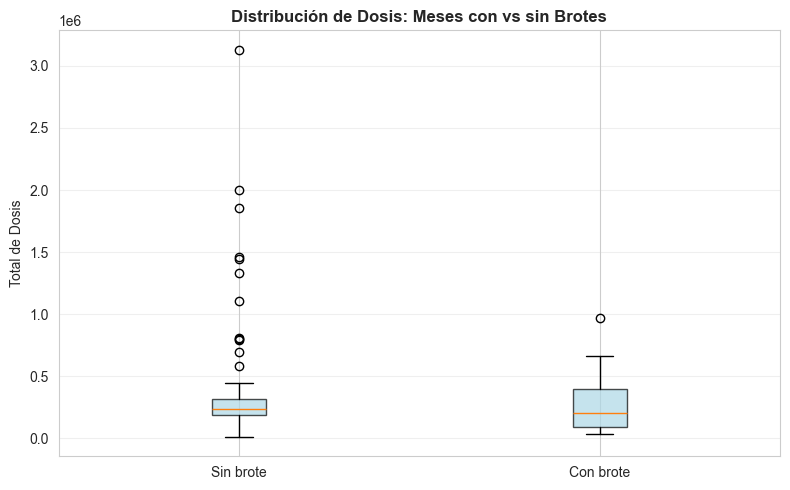

In [24]:
# Análisis bivariado considerando que la comparación directa (sin lag) tiene limitaciones.
# El efecto de la vacunación no es inmediato, por lo que primero exploramos la CCF
# para determinar si hay un lag relevante.

# Comparación descriptiva básica
sin_brote = df[df['tiene_brote'] == 0]['total_dosis']
con_brote = df[df['tiene_brote'] == 1]['total_dosis']

print('COMPARACIÓN DESCRIPTIVA: Dosis en meses con/sin brotes')
print(f'  Sin brote - Media: {sin_brote.mean():,.0f}, Mediana: {sin_brote.median():,.0f}')
print(f'  Con brote - Media: {con_brote.mean():,.0f}, Mediana: {con_brote.median():,.0f}')

# Nota sobre Mann-Whitney
stat, pval = mannwhitneyu(sin_brote, con_brote, alternative='two-sided')
print(f'\nMann-Whitney U (comparación contemporánea): U={stat:.2f}, p={pval:.4f}')
print(f'  {"Significativo" if pval < 0.05 else "No significativo"} al nivel 0.05')

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([sin_brote, con_brote], labels=['Sin brote', 'Con brote'],
           patch_artist=True, boxprops=dict(facecolor='lightblue', alpha=0.7))
ax.set_ylabel('Total de Dosis')
ax.set_title('Distribución de Dosis: Meses con vs sin Brotes', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Lag óptimo de la CCF: 13 meses
Interpretación: las dosis de 13 mes(es) atrás se comparan con los brotes actuales

COMPARACIÓN CON LAG DE 13 MES(ES)
  Meses sin brote (n=142): Mediana dosis_13m_antes = 221,248
  Meses con brote (n=13): Mediana dosis_13m_antes = 213,743

Mann-Whitney U (con lag=13): U=1044.00, p=0.4367
  No significativo al nivel 0.05


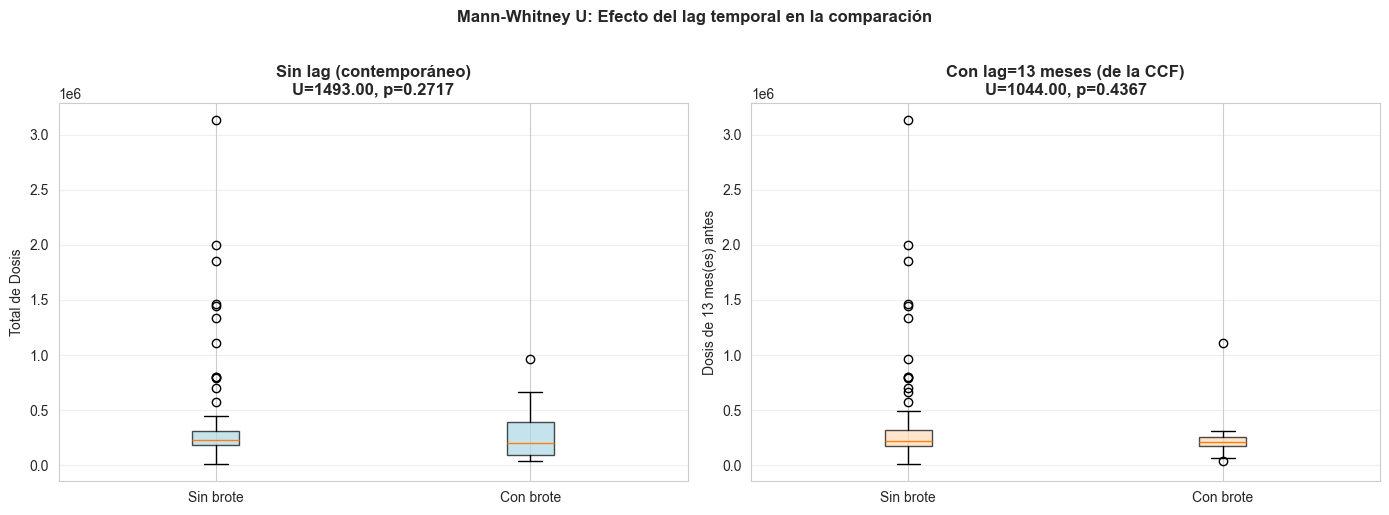

In [25]:
# Mann-Whitney U CON LAG TEMPORAL
# Usamos el lag óptimo identificado en la CCF (sección 5.3)
# La idea: comparar las dosis de N meses ANTES con la presencia/ausencia de brote actual

print(f'Lag óptimo de la CCF: {best_lag} meses')
print(f'Interpretación: las dosis de {best_lag} mes(es) atrás se comparan con los brotes actuales\n')

# Crear variable de dosis con lag
df_lagged = df.copy()
df_lagged['dosis_lag'] = df_lagged['total_dosis'].shift(best_lag)
df_lagged = df_lagged.dropna(subset=['dosis_lag'])  # Eliminar filas sin lag

sin_brote_lag = df_lagged[df_lagged['tiene_brote'] == 0]['dosis_lag']
con_brote_lag = df_lagged[df_lagged['tiene_brote'] == 1]['dosis_lag']

print(f'COMPARACIÓN CON LAG DE {best_lag} MES(ES)')
print(f'  Meses sin brote (n={len(sin_brote_lag)}): Mediana dosis_{best_lag}m_antes = {sin_brote_lag.median():,.0f}')
print(f'  Meses con brote (n={len(con_brote_lag)}): Mediana dosis_{best_lag}m_antes = {con_brote_lag.median():,.0f}')

stat_lag, pval_lag = mannwhitneyu(sin_brote_lag, con_brote_lag, alternative='two-sided')
print(f'\nMann-Whitney U (con lag={best_lag}): U={stat_lag:.2f}, p={pval_lag:.4f}')
print(f'  {"Significativo" if pval_lag < 0.05 else "No significativo"} al nivel 0.05')

# Comparación visual: contemporáneo vs con lag
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([sin_brote, con_brote], labels=['Sin brote', 'Con brote'],
                patch_artist=True, boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[0].set_ylabel('Total de Dosis')
axes[0].set_title(f'Sin lag (contemporáneo)\nU={stat:.2f}, p={pval:.4f}', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].boxplot([sin_brote_lag, con_brote_lag], labels=['Sin brote', 'Con brote'],
                patch_artist=True, boxprops=dict(facecolor='#FFDAB9', alpha=0.7))
axes[1].set_ylabel(f'Dosis de {best_lag} mes(es) antes')
axes[1].set_title(f'Con lag={best_lag} meses (de la CCF)\nU={stat_lag:.2f}, p={pval_lag:.4f}', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Mann-Whitney U: Efecto del lag temporal en la comparación', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** Se realizaron dos pruebas Mann-Whitney U:
1. **Contemporánea** (sin lag): compara las dosis del mismo mes en que ocurre/no ocurre el brote.
2. **Con lag temporal**: compara las dosis de N meses antes (lag obtenido de la CCF en la sección 5.3) con la presencia/ausencia de brote actual. Esto es más realista, ya que el efecto protector de la vacunación no es instantáneo.

La comparación con lag es más adecuada epidemiológicamente. Sin embargo, ambos enfoques tienen la limitación de no controlar por otras variables confusoras (cobertura acumulada, importación de casos, etc.), por lo que los resultados deben interpretarse con cautela.

### 6.4 Comparación por Períodos

,Período,Dosis_Total,Dosis_Promedio_Mes,Casos_Total,Meses_con_Casos
0,2010-2013,13472647,280680.145833,166,5
1,2014-2017,17662171,367961.895833,0,0
2,2018-2020,8722505,242291.805556,214,12
3,2021-2023,13116947,364359.638889,0,0


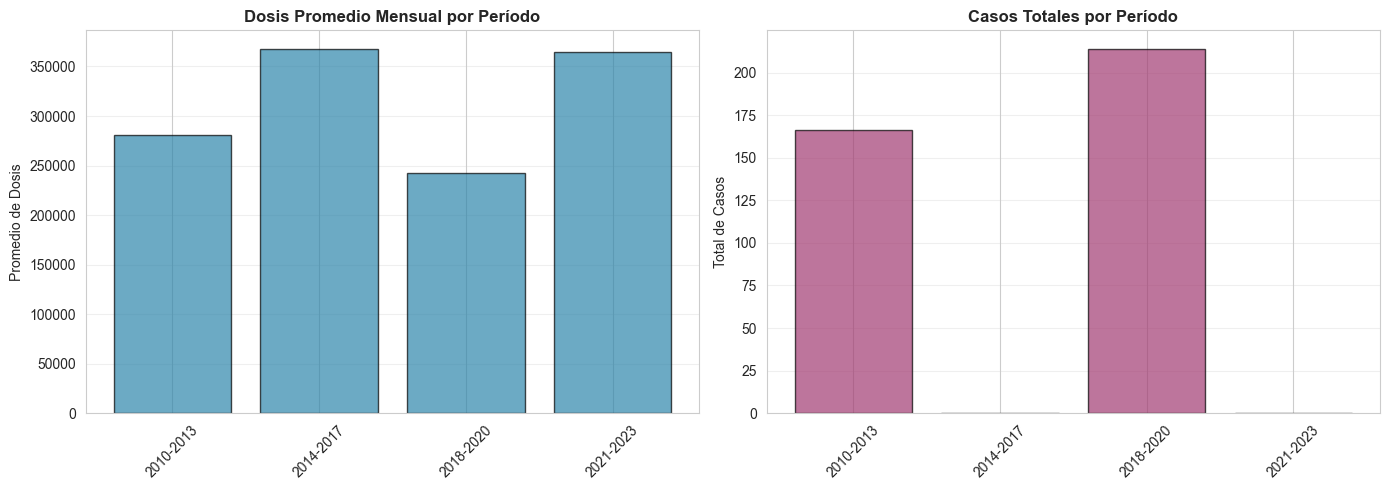

In [26]:
periodos = {
    '2010-2013': (2010, 2013),
    '2014-2017': (2014, 2017),
    '2018-2020': (2018, 2020),
    '2021-2023': (2021, 2023)
}

comp = []
for nombre, (inicio, fin) in periodos.items():
    datos = df[(df['anio'] >= inicio) & (df['anio'] <= fin)]
    comp.append({
        'Período': nombre,
        'Dosis_Total': datos['total_dosis'].sum(),
        'Dosis_Promedio_Mes': datos['total_dosis'].mean(),
        'Casos_Total': datos['casos_sarampion'].sum(),
        'Meses_con_Casos': (datos['casos_sarampion'] > 0).sum()
    })

comp_df = pd.DataFrame(comp)
display(comp_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(comp_df['Período'], comp_df['Dosis_Promedio_Mes'],
           color='#2E86AB', alpha=0.7, edgecolor='black')
axes[0].set_title('Dosis Promedio Mensual por Período', fontweight='bold')
axes[0].set_ylabel('Promedio de Dosis')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(comp_df['Período'], comp_df['Casos_Total'],
           color='#A23B72', alpha=0.7, edgecolor='black')
axes[1].set_title('Casos Totales por Período', fontweight='bold')
axes[1].set_ylabel('Total de Casos')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Preprocesamiento

Basado en los hallazgos del EDA, se aplican las transformaciones necesarias para preparar el dataset para modelado.

In [27]:
df_prep = df.copy()

# 1. Valores faltantes: No se requiere acción (0% missing)

# 2. Transformación logarítmica para reducir asimetría (outliers conservados)
df_prep['total_dosis_log'] = np.log1p(df_prep['total_dosis'])
df_prep['casos_sarampion_log'] = np.log1p(df_prep['casos_sarampion'])

# 3. Encoding cíclico para mes (captura su naturaleza circular: dic ≈ ene)
df_prep['mes_sin'] = np.sin(2 * np.pi * df_prep['mes'] / 12)
df_prep['mes_cos'] = np.cos(2 * np.pi * df_prep['mes'] / 12)

# 4. Normalización de año
df_prep['anio_normalizado'] = (df_prep['anio'] - df_prep['anio'].min()) / \
                               (df_prep['anio'].max() - df_prep['anio'].min())

print('RESUMEN DEL PREPROCESAMIENTO')
print(f'  Registros: {len(df_prep)} (0 eliminados)')
print(f'  Variables originales: anio, mes, total_dosis, casos_sarampion')
print(f'  Variables nuevas: total_dosis_log, casos_sarampion_log, mes_sin, mes_cos, anio_normalizado')
print(f'\n  Skewness total_dosis:     {skew(df_prep["total_dosis"]):.2f} → {skew(df_prep["total_dosis_log"]):.2f} (log)')
print(f'  Skewness casos_sarampion: {skew(df_prep["casos_sarampion"]):.2f} → {skew(df_prep["casos_sarampion_log"]):.2f} (log)')

display(df_prep[['anio', 'mes', 'total_dosis', 'total_dosis_log',
                 'casos_sarampion', 'casos_sarampion_log',
                 'mes_sin', 'mes_cos', 'anio_normalizado']].head())

RESUMEN DEL PREPROCESAMIENTO
  Registros: 168 (0 eliminados)
  Variables originales: anio, mes, total_dosis, casos_sarampion
  Variables nuevas: total_dosis_log, casos_sarampion_log, mes_sin, mes_cos, anio_normalizado

  Skewness total_dosis:     4.70 → 0.12 (log)
  Skewness casos_sarampion: 5.90 → 3.77 (log)


,anio,mes,total_dosis,total_dosis_log,casos_sarampion,casos_sarampion_log,mes_sin,mes_cos,anio_normalizado
0,2010,1,180830,12.105318,0,0.0,0.500000,8.660254e-01,0.0
1,2010,2,183377,12.119305,0,0.0,0.866025,5.000000e-01,0.0
2,2010,3,242572,12.399058,0,0.0,1.000000,6.123234e-17,0.0
3,2010,4,216429,12.285022,0,0.0,0.866025,-5.000000e-01,0.0
4,2010,5,174559,12.070024,0,0.0,0.500000,-8.660254e-01,0.0


**Decisiones de preprocesamiento y justificación:**

| Problema | Estrategia | Justificación |
|----------|-----------|---------------|
| Valores faltantes | Sin acción | 0% de missing values |
| Outliers | Conservar + transformación log | Representan eventos epidemiológicos reales (campañas y brotes) |
| Asimetría | Transformación log(x+1) | Reduce skewness preservando interpretabilidad |
| Variable `mes` | Encoding cíclico (sin/cos) | Captura la naturaleza circular del tiempo (diciembre ≈ enero) |
| Variable `anio` | Normalización min-max | Escala uniforme [0,1] para algoritmos de ML |

## 8. Resumen y Conclusiones

In [28]:
print('RESUMEN DEL EDA')
print('=' * 60)
print(f'\nPeríodo: {df["anio"].min()}-{df["anio"].max()} ({len(df)} meses)')
print(f'Total dosis aplicadas: {df["total_dosis"].sum():,}')
print(f'Total casos de sarampión: {df["casos_sarampion"].sum()}')
print(f'Meses con casos: {(df["casos_sarampion"] > 0).sum()} de {len(df)} ({(df["casos_sarampion"] > 0).mean()*100:.1f}%)')
print(f'Años con casos: {sorted(df[df["casos_sarampion"] > 0]["anio"].unique())}')
print(f'\nCorrelación Pearson (dosis vs casos): {pearson_corr:.4f} (p={pearson_p:.4f})')
print(f'Correlación Spearman (dosis vs casos): {spearman_corr:.4f} (p={spearman_p:.4f})')

RESUMEN DEL EDA

Período: 2010-2023 (168 meses)
Total dosis aplicadas: 52,974,270
Total casos de sarampión: 380
Meses con casos: 17 de 168 (10.1%)
Años con casos: [np.int64(2010), np.int64(2013), np.int64(2018), np.int64(2019), np.int64(2020)]

Correlación Pearson (dosis vs casos): 0.0620 (p=0.4249)
Correlación Spearman (dosis vs casos): -0.0747 (p=0.3359)


### Conclusiones del Análisis Exploratorio

#### 1. Calidad de los datos
El dataset presenta excelente calidad: 0% de valores faltantes, 168 registros mensuales consecutivos, y tipos de datos consistentes. Los valores atípicos detectados (campañas intensivas y brotes) son eventos reales que se conservan en el análisis.

#### 2. Naturaleza temporal de los datos
- **Tendencia:** No se detecta tendencia lineal significativa en ninguna variable. La descomposición de la serie revela patrones no lineales con períodos de incremento y decremento.
- **Estacionalidad:** Las dosis de vacunas muestran un patrón estacional claro. Los casos de sarampión no presentan estacionalidad marcada; los brotes son esporádicos.
- **Estacionaridad:** Las pruebas ADF y KPSS proporcionan evidencia sobre si las series requieren diferenciación para modelado.

#### 3. Relación entre vacunación y casos
- La correlación contemporánea es débil, lo que refleja que el efecto de la vacunación tiene un desfase temporal.
- La correlación cruzada (CCF) permite identificar en qué lag la relación es más fuerte, información crucial para el modelado predictivo.
- La comparación Mann-Whitney debe interpretarse con cautela por la ausencia de consideración del desfase temporal, ya que esta pro validarse el desfase optimo basado en los comentarios de las doctoras.

#### 4. Brotes y desequilibrio de clases
- Los brotes son eventos raros (~10% de meses), lo cual genera desequilibrio de clases.
- Para predicción de brotes en series de tiempo, se recomienda usar pesos de clase y métricas apropiadas (F1, AUC-ROC), evitando técnicas como SMOTE que pueden generar data leakage temporal.

#### 5. Próximos pasos
- Validar si se tienen datos de vacunación de 2024-2025 disponibles para agregarlos junto a lso de boletines epidemiológicos.
- Desarrollar modelos de series de tiempo (ARIMA, Prophet, Poisson, Negative Binomial, Z-scores, Isolation Forest, Bayesian Hierarchical Models, State Space) considerando los resultados de estacionaridad.
- Consultar con las doctoras del dominio para validar el lag temporal obtenido de la CCF.